<div style="margin-top: 40px; margin-bottom: 55px;">

<h1 style="font-size: 36px; font-weight: 500; margin-bottom: 24px;">
Modeling Housing Prices on Structured Data
</h1>

<h2 style="font-size: 25px; font-weight: 400; margin-bottom: 24px;">
An End-to-End Comparison of Predictive Performance and Feature Influence
</h2>

<p style="font-size: 18px; margin-bottom: 8px;">
Sebastian Villarroel
</p>

<p style="font-size: 18px; margin-top: 0;">
07/17/2026
</p>

</div>

#1. Introduction

Accurately predicting housing prices is an important challenge in real estate, urban economics, and data science. Reliable price estimates help buyers, sellers, lenders, and policymakers make better-informed decisions. Traditional valuation methods, such as comparative market analysis and hedonic regression, provide useful insights but may struggle to capture complex and nonlinear relationships among structural features, neighborhood characteristics, and market conditions.

In this project, I evaluated how well different statistical and machine learning models predicted home sale prices using the Ames Housing dataset. This dataset is widely used for housing-price modeling and contains detailed information about property characteristics, including size, quality, condition, age, and location. The project also examined which property features were most important to the final model.

##Goals

The goals of this project were:

- Compare the predictive performance of models ranging from traditional regression methods to more advanced machine learning approaches, using root mean squared error, or RMSE, as the primary evaluation metric.

- Identify which property characteristics most strongly influenced housing values in the chosen model.

The models evaluated in this project ranged from traditional linear regression methods to tree-based models, ensemble approaches, nearest-neighbor methods, and deep learning. By systematically comparing these approaches, the project aimed to determine which model provided the strongest predictive performance while still offering useful insight into the factors associated with housing prices.

In [1]:
#Importing libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Gradient boosting
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Data
from sklearn.datasets import fetch_openml

##2. Data Loading, Basic Feature Engineering, and Train-Test Split

The Ames Housing dataset was loaded using the **fetch_openml()** function and stored as a pandas DataFrame. Two additional features were then created:

- Has_Garage: a binary indicator coded as 1 if the home had a garage and 0 otherwise. This feature was derived from GarageArea.

- Age: a numeric variable calculated as YrSold - YearBuilt, representing the age of the property at the time of sale.

The dataset was then divided into training and testing sets using an 80/20 split. The training set was used for exploratory data analysis, preprocessing, model development, and model comparison, while the test set was reserved for the final evaluation of the selected model. A fixed random seed was used to ensure that the split could be reproduced.

In [2]:
# Loading data
ames = fetch_openml(name="house_prices", as_frame=True)
df = ames.frame

# Basic Feature engineering
df["Has_Garage"] = (df["GarageArea"] > 0).astype(int)
df["Age"] = df["YrSold"] - df["YearBuilt"]

# Train, test split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=123
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)



##3. Data Quality Assessment and EDA Preparation

A separate copy of the training set was created for exploratory data analysis. This allowed the data to be cleaned and summarized for visualization without modifying the original training data that would later be used in the modeling pipeline.

The initial quality assessment focused on missing values and duplicate observations. No duplicated rows or duplicated property IDs were identified.

Missing values were handled according to the meaning of each variable:

- For categorical features in which a missing value indicated the absence of an amenity or property attribute, such as a pool, alley, fence, fireplace, garage, basement, or masonry veneer, missing values were replaced with "None".

- The missing value in Electrical was handled differently because it represented an unknown category rather than the absence of an electrical system. It was therefore imputed using the most frequently occurring electrical system in the training data.

- For numerical features in which a missing value represented the absence of the corresponding feature, such as GarageYrBlt and MasVnrArea, missing values were replaced with 0.

- Missing values in LotFrontage were treated as genuinely unavailable measurements rather than as the absence of a property characteristic. These values were therefore imputed using the median frontage observed in the training data.

These transformations were applied only to the EDA copy of the training set. The preprocessing steps used for model development were handled separately to reduce the risk of data leakage and ensure consistent transformations during cross-validation and final evaluation.

In [3]:
# Data used for eda
train_eda = train_df.copy()

# 1. Checking for missing vals

missing_summary = pd.DataFrame({
    "missing_count": train_eda.isna().sum(),
    "missing_percentage": train_eda.isna().mean() * 100
}).sort_values("missing_count",ascending=False)

## missing_summary[missing_summary["missing_count"] > 0]

# 1.1 Handling missing categorical variables

categorical_cols = train_eda.select_dtypes(include=["object", "category"]).columns
## categorical_cols

none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageFinish", "GarageQual", "GarageType", "GarageCond",
    "BsmtExposure", "BsmtQual", "BsmtCond", "BsmtFinType1",
    "BsmtFinType2", "MasVnrType"
]

for col in none_cols:
  if col in train_eda.columns:
    train_eda[col] = train_eda[col].fillna("None")

mode_cols = ["Electrical"]

for col in mode_cols:
    if col in train_eda.columns:
        train_eda[col] = train_eda[col].fillna(train_eda[col].mode()[0])

# # 1.2 Handling missing numerical variables

zero_cols = ["GarageYrBlt", "MasVnrArea"]

for col in zero_cols:
  if col in train_eda.columns:
    train_eda[col] = train_eda[col].fillna(0)

median_cols = ["LotFrontage"]

for col in median_cols:
  train_eda[col] = train_eda[col].fillna(train_eda[col].median())

# 2. Checking for duplicates

duplicate_count = train_eda.duplicated().sum()
duplicate_id_count = train_eda["Id"].duplicated().sum()

duplicated_summary = pd.DataFrame({
    "duplicated_count": [duplicate_count],
    "duplicated_Id_count": [duplicate_id_count]
}).sort_values("duplicated_count", ascending=False)

#duplicated_summary

##4. Exploratory Data Analysis (EDA)

Exploratory data analysis was conducted using only the training data to better understand the target variable and its relationships with key property characteristics. Keeping the test set separate ensured that it remained unseen during data exploration and model development.

The analysis began by examining the distribution of SalePrice and evaluating whether a transformation would be appropriate for modeling. Descriptive summaries and visualizations were then used to explore how sale prices varied across selected categorical features, including overall quality and garage availability. Scatterplots were also used to examine relationships between sale price and numerical features such as above-ground living area and property age.

Finally, broader feature-target relationships were assessed using Pearson correlations for numerical variables and one-way ANOVA tests for categorical variables. These analyses were used to identify potentially informative predictors and guide the selection of features for the baseline linear regression model.

**Sale Price Distribution and Target Transformation**

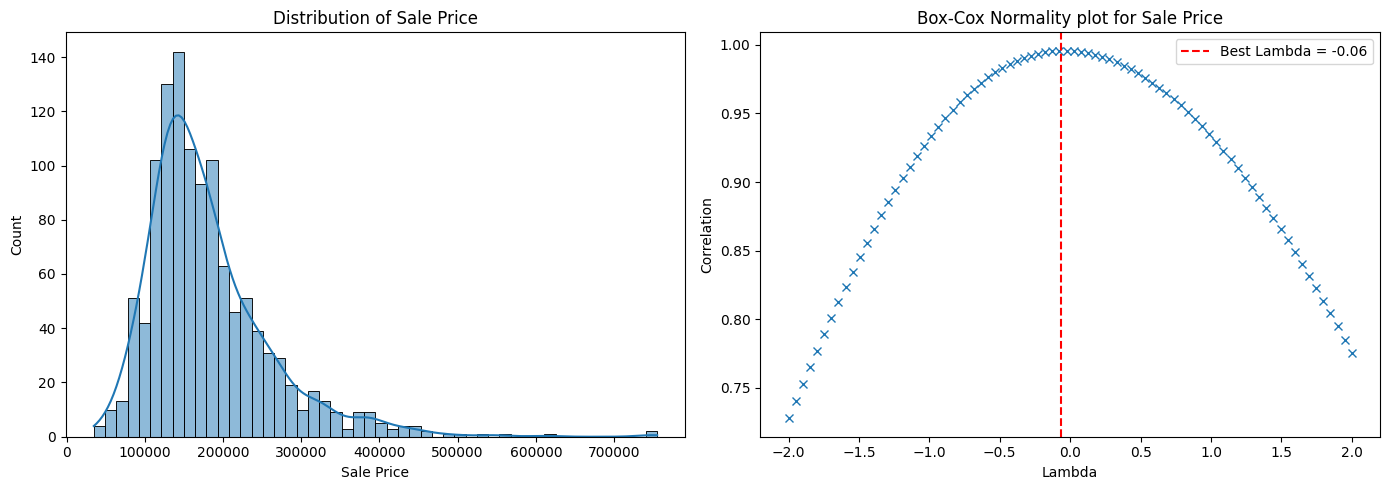



Optimal Box_cox lambda: -0.06284093680849011


In [4]:
from scipy.stats import skew
from scipy import stats

# Sale Price
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(train_eda["SalePrice"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Sale Price")
axes[0].set_xlabel("Sale Price")
axes[0].set_ylabel("Count")

# Box-Cox
sale_price = train_eda["SalePrice"]
transformed_saleprice, fitted_lambda =stats.boxcox(sale_price)

stats.boxcox_normplot(sale_price, -2, 2, plot=axes[1])
axes[1].axvline(fitted_lambda, color= "red", linestyle= "--",
               label=f"Best Lambda = {fitted_lambda:.2f}")
axes[1].set_title("Box-Cox Normality plot for Sale Price")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Correlation")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n")
print("Optimal Box_cox lambda:", fitted_lambda)


The distribution of SalePrice was strongly right-skewed, with most homes concentrated in the lower and middle price ranges and a smaller number of high-value properties extending the upper tail. This skewness can make modeling more difficult, particularly for methods that perform better when the target is more symmetric and residual variance is more stable.

To identify an appropriate transformation, a Box-Cox analysis was applied to the training-set sale prices. The estimated optimal parameter was approximately -0.06, which is close to zero. Because a Box-Cox parameter near zero corresponds closely to a logarithmic transformation, the natural logarithm of SalePrice was selected as the modeling target.

**Distribution of Log Sale Price**

In [5]:
# Adding Log_SalePrice to the data set
train_df["Log_SalePrice"] = np.log(train_df["SalePrice"])
test_df["Log_SalePrice"] = np.log(test_df["SalePrice"])

train_eda["Log_SalePrice"] = np.log(train_eda["SalePrice"])

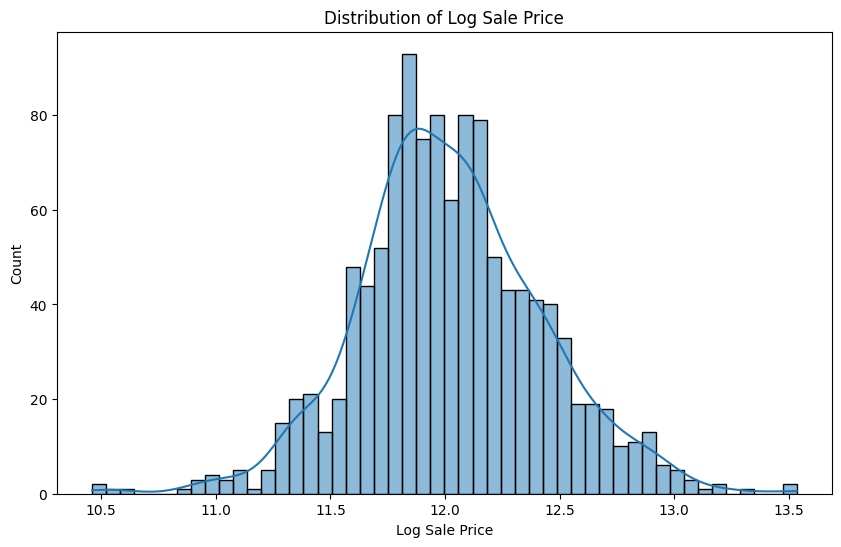



Sale Price skewness: 1.8520713364785812
Log Sale Price skewness: 0.09851575336335681


In [6]:
# Log Sale Price

plt.figure(figsize=(10,6))
sns.histplot(train_eda["Log_SalePrice"], bins=50, kde=True)
plt.title("Distribution of Log Sale Price")
plt.xlabel("Log Sale Price")
plt.ylabel("Count")
plt.show()

print("\n")
print("Sale Price skewness:", skew(train_eda["SalePrice"]))
print("Log Sale Price skewness:", skew(train_eda["Log_SalePrice"]))

The log transformation reduced skewness from approximately 1.85 to 0.10, producing a considerably more symmetric distribution. Based on this result, Log_SalePrice was used as the response variable throughout the model-building process.

**Sale Price by Overall Quality**

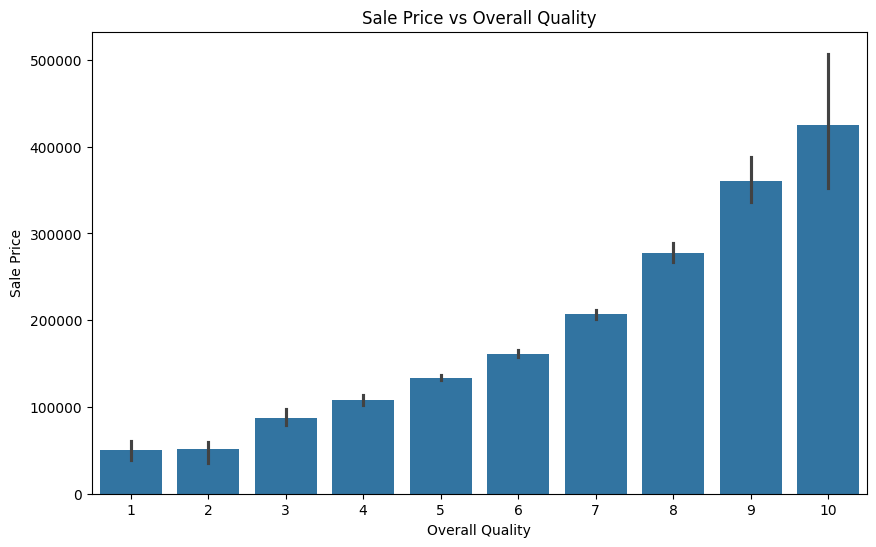

,Count,MeanPrice,MedianPrice,SDPrice
OverallQual,,,,
1,2,50150.00,50150.0,15344.22
2,3,51770.33,60000.0,14254.20
3,17,87445.59,85000.0,22020.28
4,95,108190.40,108000.0,29398.20
5,320,133870.36,132500.0,28101.81
6,290,161142.26,159000.0,35599.93
7,254,206996.07,200050.0,43527.65
8,139,277615.60,270000.0,67593.95
9,32,360229.09,339084.0,76589.43


In [7]:
## Sale Price by Overall Quality

plt.figure(figsize=(10,6))
sns.barplot(train_eda, x="OverallQual", y="SalePrice")
plt.title("Sale Price vs Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.show()

print("\n")

## Summary Table
train_eda.groupby("OverallQual")["SalePrice"].agg(
    Count="count",
    MeanPrice="mean",
    MedianPrice="median",
    SDPrice="std"
).round(2)

The bar plot and summary statistics show a strong positive relationship between overall quality and sale price. As overall quality increases, both the average sale price and median sale price tend to rise. Lower-rated homes generally sell for less and show relatively limited price variation, while higher-quality homes sell for higher prices and display greater variability.

For example, homes rated as 5 have an average sale price of approximately \$134,000, with a standard deviation of about \$28,000. In comparison, homes rated as 10 have an average sale price of approximately \$425,000, with a much larger standard deviation of about \$162,000. This suggests that overall quality is strongly associated with housing prices, but price variation also increases among higher-quality homes.

**Sale Price by Garage Presence**

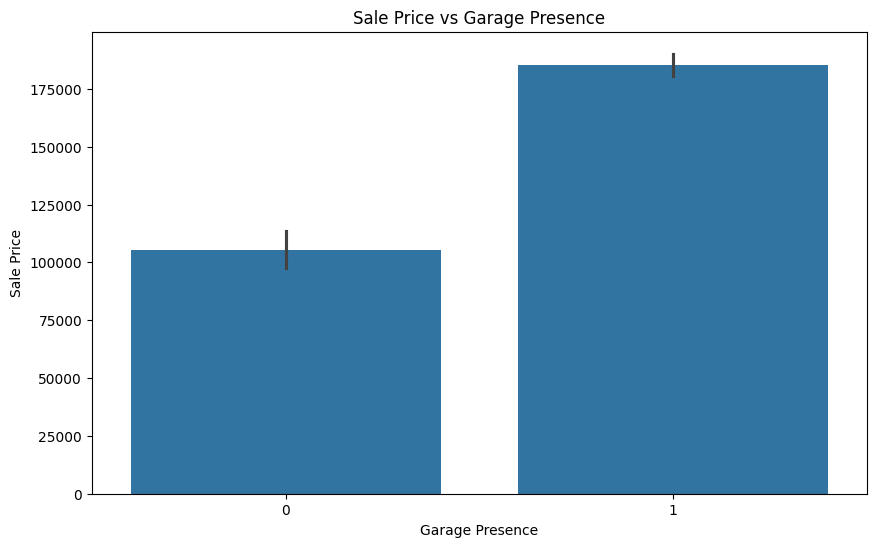

,Count,MeanPrice,MedianPrice,SDPrice
Has_Garage,,,,
0,67,105189.55,102000.0,33398.95
1,1101,185313.20,167000.0,79339.00


In [8]:
## Sale Price by Garage Presence

plt.figure(figsize=(10,6))
sns.barplot(train_eda, x="Has_Garage", y="SalePrice")
plt.title("Sale Price vs Garage Presence")
plt.xlabel("Garage Presence")
plt.ylabel("Sale Price")
plt.show()

print("\n")

train_eda.groupby("Has_Garage")["SalePrice"].agg(
    Count="count",
    MeanPrice="mean",
    MedianPrice="median",
    SDPrice="std"
).round(2)

The results indicate a clear difference in sale prices between homes with and without a garage. Properties without a garage sold for an average of approximately \$105,000, while homes with a garage sold for an average of about \$185,000. This represents an average price difference of roughly \$80,000.

The median sale price was higher for homes with a garage, and they also showed greater variability. The standard deviation was approximately \$79,000 for homes with a garage, compared with about \$33,000 for homes without one. However, the group without a garage contained only 67 observations, while the group with a garage contained 1,101 observations, so the estimates for homes without a garage should be interpreted with greater caution.

Overall, garage presence appears to be strongly associated with higher sale prices. However, this relationship should not be interpreted as causal, since homes with garages may also differ in size, quality, location, and other characteristics that influence property value.

**Sale Price vs Living Area**

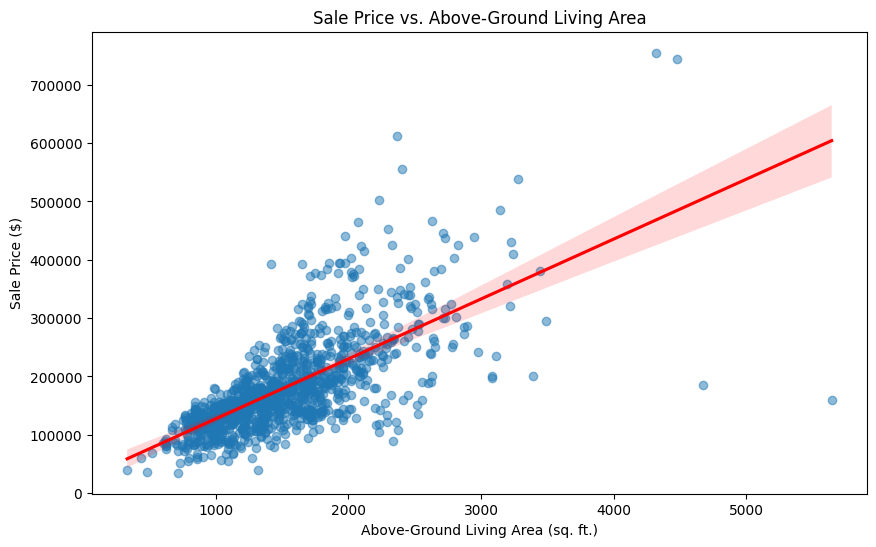

In [9]:
## Sale Price vs Living Area

plt.figure(figsize=(10,6))
sns.regplot(train_eda, x="GrLivArea", y="SalePrice", scatter_kws={"alpha": 0.5},
            line_kws={"color": "red"})
plt.title("Sale Price vs. Above-Ground Living Area")
plt.xlabel("Above-Ground Living Area (sq. ft.)")
plt.ylabel("Sale Price ($)")
plt.show()


The scatterplot shows a clear positive relationship between above-ground living area and sale price. In general, larger homes tend to sell for higher prices, suggesting that GrLivArea is an important predictor of housing value.

The relationship appears approximately linear for most properties, although the variability in sale prices increases as living area becomes larger. This wider spread among larger homes suggests possible heteroscedasticity, meaning that the variance of sale prices is not constant across all levels of living area.

**Sale Price vs Property Age**

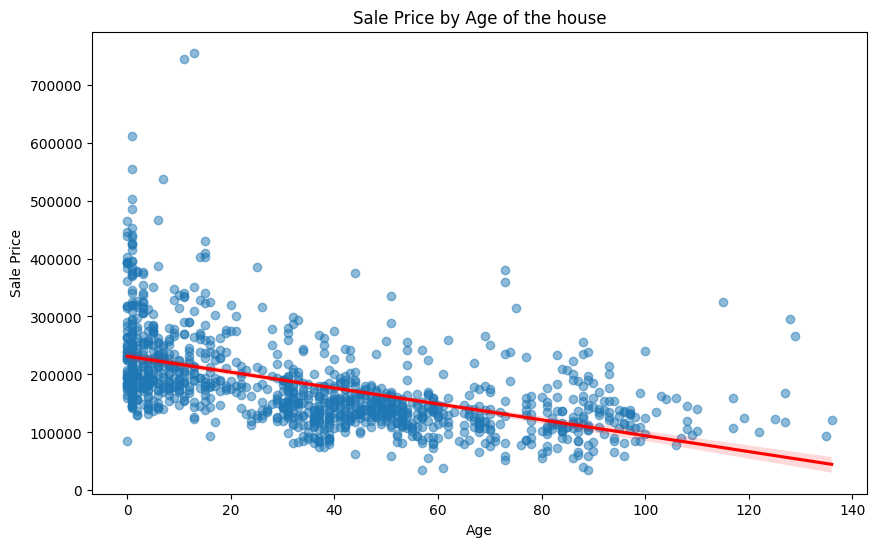

In [10]:
## Sale Price vs Age

plt.figure(figsize=(10,6))
sns.regplot(train_eda, x="Age", y="SalePrice", scatter_kws={"alpha": 0.5},
            line_kws={"color": "red"})
plt.title("Sale Price by Age of the house")
plt.xlabel("Age")
plt.ylabel("Sale Price")
plt.show()

The scatterplot shows a negative relationship between property age and sale price. In general, newer homes tend to sell for higher prices, while older homes are associated with lower sale prices.

However, the relationship is not perfectly linear, and there is considerable variation among homes of similar ages. This indicates that age alone does not determine a property's value and that other factors also play important roles.

The plot also shows greater price variability among newer homes. Some recently built properties sold for substantially higher prices than the overall trend would suggest, while older homes were more concentrated in the lower price range. A few older properties also sold for relatively high prices, which may reflect renovations, favorable locations, or other valuable characteristics.

**Numerical Correlations and Categorical Associations**

In [11]:
## Correlation with Log_SalePrice / Numerical features

numerical_predictors = train_eda.select_dtypes(
    include=["int64","float64"]
    ).drop(columns=["SalePrice", "Log_SalePrice"])

corr_with_target = (
    numerical_predictors
    .corrwith(train_eda["Log_SalePrice"])
    .sort_values(ascending=False)
    )

print("Top 8 positive correlated features:")
print(corr_with_target.head(8))
print("\n")
print("Top 5 negative correlated features:")
print(corr_with_target.tail(5))


Top 8 positive correlated features:
OverallQual    0.816750
GrLivArea      0.690039
GarageCars     0.675839
GarageArea     0.647121
TotalBsmtSF    0.614156
1stFlrSF       0.608941
FullBath       0.592462
YearBuilt      0.579420
dtype: float64


Top 5 negative correlated features:
LowQualFinSF    -0.058690
MSSubClass      -0.091929
KitchenAbvGr    -0.151497
EnclosedPorch   -0.153000
Age             -0.579704
dtype: float64


In [12]:
## Categorical association with Log_SalePrice
from scipy.stats import f_oneway

cat_cols = train_eda.select_dtypes(include=["object", "category"]).columns

anova_results=[]

for col in cat_cols:
  groups = [
      group["Log_SalePrice"].dropna()
      for name, group in train_eda.groupby(col)
  ]

  if len(groups) > 1:
    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        "variable": col,
        "f_statistic": f_stat,
        "p_value": p_value
    })

anova_df = pd.DataFrame(anova_results).sort_values("p_value")

print("Top 8 categorical associations:")
print(anova_df.head(8))

Top 8 categorical associations:
        variable  f_statistic        p_value
8   Neighborhood    64.846295  7.305559e-194
18     ExterQual   331.092832  2.081767e-155
21      BsmtQual   236.784044  9.254873e-149
30   KitchenQual   294.821530  2.435464e-142
34  GarageFinish   230.815811  1.710022e-117
33    GarageType    95.408840   1.644907e-97
32   FireplaceQu   105.581410   5.820963e-92
20    Foundation   101.594406   5.520756e-89


To identify variables that may be useful for predicting housing prices, numerical and categorical features were evaluated separately against Log_SalePrice.

For numerical variables, Pearson correlation coefficients were calculated to measure the strength and direction of their linear relationships with the log-transformed target. OverallQual showed the strongest positive correlation with Log_SalePrice, followed by GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and 1stFlrSF. Property age had the strongest negative correlation, indicating that older homes generally tended to sell for lower prices.

For categorical variables, one-way ANOVA tests were used to determine whether mean Log_SalePrice differed across category levels. The results indicated that variables such as ExterQual, BsmtQual, KitchenQual, GarageFinish, GarageType, FireplaceQu, and Foundation were strongly associated with the target.

These results were used as an initial guide for feature selection. However, correlation coefficients and ANOVA p-values were not treated as direct measures of overall feature importance. Final predictor selection also considered domain knowledge, redundancy among variables, interpretability, and relevance to the housing-price problem.

The variables selected for the baseline model included OverallQual, GrLivArea, Age, GarageArea, TotalBsmtSF, Neighborhood, ExterQual, KitchenQual, Foundation, and PoolArea.

##5. Data Preprocessing

Before model development, the predictor variables were separated from the target. **Log_SalePrice** was used as the response variable, while both SalePrice and Log_SalePrice were removed from the feature matrices to prevent target leakage.

The predictors were then divided into numerical and categorical groups. Missing values were handled according to the meaning of each feature rather than applying the same imputation strategy to every variable.

For numerical variables:

- Missing values in numerical variables such as **GarageYrBlt** and **MasVnrArea**, where missingness represented the absence of a property feature, were imputed with 0.

- Missing values in other numerical features were treated as genuinely missing measurements and imputed with the median calculated from the training data.

- All numerical predictors were standardized using **StandardScaler** so that they were placed on a comparable scale.

For categorical variables:

- Missing values in **Electrical** were imputed using the most frequently observed category because a missing value did not indicate the absence of an electrical system.

- Missing values in the remaining categorical features were assigned the category "None" when missingness represented the absence of the corresponding property attribute.

- Categorical variables were converted into numerical indicator variables using one-hot encoding. The option **handle_unknown="ignore"** ensured that categories appearing in validation or test data but not in the training data would not cause errors.

The preprocessing steps were combined using a **ColumnTransformer**. This preprocessor was later included within each modeling pipeline so that imputation, scaling, and encoding were learned only from the training folds during cross-validation. This approach reduced the risk of data leakage and ensured that the same transformations were applied consistently to validation and test observations.

In [13]:
#1. Separate X and Y

target = "Log_SalePrice"

X_train = train_df.drop(columns=["SalePrice","Log_SalePrice"])
y_train = train_df[target]

X_test = test_df.drop(columns=["SalePrice","Log_SalePrice"])
y_test = test_df[target]

#2. Pre-processing

numerical_features = X_train.select_dtypes(include=["int64","float64"]).columns
categorical_features = X_train.select_dtypes(include=["object","category"]).columns

## Feature groups based on the meaning of missing values
numerical_zero_features = ["GarageYrBlt", "MasVnrArea"]
numerical_median_features = [
    col for col in numerical_features
    if col not in numerical_zero_features
]

categorical_mode_features = ["Electrical"]
categorical_none_features = [
    col for col in categorical_features
    if col not in categorical_mode_features
]

## Pipelines for each group

numerical_zero_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

numerical_median_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_mode_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_none_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined
preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero", numerical_zero_transformer, numerical_zero_features),
        ("num_median", numerical_median_transformer, numerical_median_features),
        ("cat_mode", categorical_mode_transformer, categorical_mode_features),
        ("cat_none", categorical_none_transformer, categorical_none_features)
    ]
)

##6. Model Building and Selection

Several regression models were developed and compared to determine which approach most accurately predicted home sale prices, ranging from interpretable linear models to nonlinear ensemble and deep learning approaches:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- XGBoost Regression
- K-Nearest Neighbors Regression
- Deep Learning

For the traditional machine learning models, the preprocessing pipeline described in Section 4 was incorporated directly into each modeling pipeline. This ensured that imputation, scaling, and one-hot encoding were learned only from the training folds during cross-validation and then applied to the corresponding validation fold. This approach reduced the risk of data leakage and ensured that preprocessing was performed consistently across models.

Model performance was primarily evaluated using root mean squared error on the log-transformed sale price. Lower RMSE values indicated better predictive performance. Cross-validation was used to estimate performance and tune hyperparameters using only the training data. Ten-fold cross-validation was used for Linear Regression, Ridge, Lasso, Decision Tree, and K-Nearest Neighbors, while five-fold cross-validation was used for Random Forest and XGBoost to reduce computation time.

Because neural network training was considerably more computationally expensive, the deep learning model was evaluated using a separate validation split from the training data rather than cross-validation. The preprocessing pipeline was fitted only on the neural-network training portion and then applied to the validation data. Early stopping was used to restore the model weights from the epoch with the best validation performance and reduce overfitting.

The test set remained untouched throughout preprocessing decisions, model development, hyperparameter tuning, and model comparison. After the models were compared, the approach with the strongest validation performance was selected and evaluated once on the previously unseen test set.

**Linear Regression**

A multiple linear regression model was developed as the baseline for the model comparison. Rather than using the full feature set, the model was trained on a smaller group of predictors selected through exploratory analysis, statistical associations, domain knowledge, and interpretability.

The selected predictors included overall quality, above-ground living area, property age, garage area, basement area, neighborhood, exterior quality, kitchen quality, foundation type, and pool area. A separate preprocessing pipeline was created for this reduced feature set before fitting the model.

Its cross-validation performance provided a reference point for evaluating whether more flexible models produced meaningful improvements.

In [14]:
# Baseline Linear Regression Model

baseline_features = ["OverallQual", "GrLivArea", "Age", "GarageArea",
                     "TotalBsmtSF", "Neighborhood", "ExterQual",
                     "KitchenQual", "Foundation","PoolArea"
                     ]


X_train_base = X_train[baseline_features]
X_test_base = X_test[baseline_features]

# Built the same preprocessor as before but only for this set of features

numeric_features_base = X_train_base.select_dtypes(
    include=["int64","float64"]).columns
cat_features_base = X_train_base.select_dtypes(
    include=["object","category"]).columns

numerical_zero_features_base = []

# Pipelines for the selected predictors

numeric_transformer_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scalar", StandardScaler())
])

cat_transformer_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_base, numeric_features_base),
        ("cat", cat_transformer_base, cat_features_base)
    ]
)

regression_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_base),
    ("model", LinearRegression())
])

# CV for the regression model

regression_rmse_scores = -cross_val_score(
    regression_pipeline,
    X_train_base,
    y_train,
    cv=10,
    scoring="neg_root_mean_squared_error"
)

print("Baseline Linear Regression CV RMSE:", regression_rmse_scores.mean())

Baseline Linear Regression CV RMSE: 0.16909758124008087


**Ridge Regression**

Ridge regression was evaluated as a regularized extension of linear regression. Its L2 penalty shrinks coefficient estimates, which can improve model stability when predictors are strongly correlated.

Unlike Lasso, Ridge retains all predictors in the model. The regularization parameter α was tuned using GridSearchCV to determine the amount of coefficient shrinkage that produced the best validation performance.


In [15]:
# Ridge model

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
ridge_rmse = -ridge_grid.best_score_
print("Best Ridge alpha:", ridge_grid.best_params_["model__alpha"])
print("Ridge CV RMSE:", ridge_rmse)


Best Ridge alpha: 10
Ridge CV RMSE: 0.14877003407312023


**Lasso Regression**

Lasso regression was used to examine whether a simpler and more selective linear model could achieve competitive performance. Its L1 penalty can shrink some coefficients to exactly zero, effectively removing predictors that contribute little to the model.

The regularization parameter α was tuned using GridSearchCV. This allowed the model to balance predictive accuracy with a more compact set of predictors.


In [16]:
# Lasso model

lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso())
])

lasso_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)
lasso_rmse = -lasso_grid.best_score_
print("Best Lasso alpha:", lasso_grid.best_params_["model__alpha"])
print("Lasso CV RMSE:", lasso_rmse)

Best Lasso alpha: 0.01
Lasso CV RMSE: 0.1621574901573505


**Decision Tree**

A decision tree regressor was included as a nonlinear alternative to the linear models. The model generated predictions by repeatedly splitting the feature space into smaller groups based on predictor values.

Because unrestricted trees can easily overfit the training data, the parameters max_depth, min_samples_leaf, and ccp_alpha were tuned to control tree complexity and reduce overfitting.

In [17]:
# Decision tree model

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=123))
])

tree_param_grid = {
    "model__ccp_alpha": [0.0, 0.0001, 0.01, 0.1, 0.02],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
tree_rmse = -tree_grid.best_score_

print("Best Decision Tree Hyperparameters:")

for parameter, value in tree_grid.best_params_.items():
    clean_name = parameter.replace("model__", "")
    print(f"{clean_name}: {value}")

print("\nDecision Tree CV RMSE:", tree_rmse)

Best Decision Tree Hyperparameters:
ccp_alpha: 0.0
max_depth: None
min_samples_leaf: 10

Decision Tree CV RMSE: 0.20243729695013934


**Random Forest Regression**

Random Forest was used to improve on the instability of a single decision tree. The model combined predictions from many trees, each trained on a bootstrap sample of the data and using a subset of predictors at each split.

Because the number of possible hyperparameter combinations was relatively large, RandomizedSearchCV was used instead of evaluating every combination. The search tuned maximum tree depth, the proportion of predictors considered at each split, the minimum number of observations required to split a node, and the minimum number allowed in a terminal leaf.

In [18]:
# Random Forest

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=123,
                                    n_estimators=150,
                                    n_jobs=-1))
])

rf_param_grid = {
    "model__max_features": ["sqrt", 0.3, 0.5, 0.7],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__min_samples_split": [2, 5, 10]
}

rf_grid = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=123,
    verbose=0
)

rf_grid.fit(X_train, y_train)
rf_rmse = -rf_grid.best_score_

print("Best Random Forest Hyperparameters:")

for parameter, value in rf_grid.best_params_.items():
    clean_name = parameter.replace("model__", "")
    print(f"{clean_name}: {value}")

print("\nRandom Forest CV RMSE:", rf_rmse)

Best Random Forest Hyperparameters:
min_samples_split: 2
min_samples_leaf: 2
max_features: 0.3
max_depth: 20

Random Forest CV RMSE: 0.1454769218630116


**XGBoost Regression**

XGBoost was included as an advanced boosting method capable of modeling nonlinear relationships and interactions among predictors. Unlike Random Forest, which builds trees independently, XGBoost adds trees sequentially so that each new tree focuses on reducing errors made by the existing ensemble.

RandomizedSearchCV was used to tune tree depth, learning rate, row subsampling, and column subsampling. Regularization and subsampling were included to improve generalization and reduce overfitting.

In [19]:
# XGBoost model

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=123,
        n_estimators=150,
        tree_method="hist",
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__max_depth": [3, 6, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9],
    "model__colsample_bytree": [0.7, 0.9]
}

xgb_grid = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=15,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=123,
    verbose=0
)

xgb_grid.fit(X_train, y_train)
xgb_rmse = -xgb_grid.best_score_

print("Best XGBoost Hyperparameters:")

for parameter, value in xgb_grid.best_params_.items():
    clean_name = parameter.replace("model__", "")
    print(f"{clean_name}: {value}")

print("\nXGBoost CV RMSE:", xgb_rmse)

Best XGBoost Hyperparameters:
subsample: 0.7
max_depth: 3
learning_rate: 0.1
colsample_bytree: 0.7

XGBoost CV RMSE: 0.1334290580711475


**K-Nearest Neighbor Regression**

K-Nearest Neighbors regression was included as a distance-based approach. Instead of estimating a fixed equation, the model predicted a property's sale price using the outcomes of nearby observations in the transformed feature space.

Because distance calculations are sensitive to feature scale, standardized predictors were especially important for this model. GridSearchCV was used to tune the number of neighbors, the weighting method, and the distance metric. A value of p=1 represented Manhattan distance, while p=2 represented Euclidean distance.

In [ ]:
# KNN model

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 9, 15, 30],
    "model__weights": ["uniform", "distance"],
    "model__p": [1,2]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)
knn_rmse = -knn_grid.best_score_

print("Best KNN Hyperparameters:")

for parameter, value in knn_grid.best_params_.items():
    clean_name = parameter.replace("model__", "")
    print(f"{clean_name}: {value}")

print("\nKNN CV RMSE:", knn_rmse)


**Deep Learning**

A feedforward neural network was included to test whether a more flexible model could capture complex nonlinear relationships among the housing features.

The network contained three hidden layers with 256, 128, and 64 neurons, each using ReLU activation. Dropout layers with rates of 0.4 and 0.3 were added after the first two hidden layers to reduce overfitting. The model was trained using the Adam optimizer with a learning rate of 0.0005 and mean squared error as the loss function.

Training was allowed to continue for up to 200 epochs with a batch size of 32. Early stopping monitored validation loss and restored the weights from the best-performing epoch when performance stopped improving.

In [21]:
# Deep learning model

# Since Deep learning is more computationally expensive,
# we use a validation set instead of CV

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=123
)

X_train_nn_processed = preprocessor.fit_transform(X_train_nn)
X_val_nn_processed = preprocessor.transform(X_val_nn)

# If the processed data is sparse, convert it to dense
if hasattr(X_train_nn_processed, "toarray"):
    X_train_nn_processed = X_train_nn_processed.toarray()

if hasattr(X_val_nn_processed, "toarray"):
    X_val_nn_processed = X_val_nn_processed.toarray()

# Built the NN
tf.random.set_seed(123)

deep_model = keras.Sequential([
    layers.Input(shape=(X_train_nn_processed.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dense(1)
])

deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train the model
history = deep_model.fit(
    X_train_nn_processed,
    y_train_nn,
    validation_data=(X_val_nn_processed, y_val_nn),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

pred_val_nn = deep_model.predict(X_val_nn_processed).flatten()

nn_mse = mean_squared_error(y_val_nn, pred_val_nn)
nn_rmse = np.sqrt(nn_mse)

best_epoch = np.argmin(history.history["val_loss"]) + 1
epochs_completed = len(history.history["loss"])

print("Epochs completed:", epochs_completed)
print("Best epoch:", best_epoch)
print("Deep Learning Validation RMSE:", nn_rmse)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epochs completed: 14
Best epoch: 4
Deep Learning Validation RMSE: 0.8582512984205177


**Model Comparisons**

The models were compared using RMSE on the log-transformed sale price, with lower values indicating better predictive performance. Because the models were evaluated using different validation procedures, particularly the neural network, the RMSE values should be interpreted as approximate comparisons rather than perfectly equivalent estimates.

XGBoost achieved the lowest RMSE at approximately 0.1334, followed by Random Forest at 0.1455 and Ridge Regression at 0.1488. The tree-based ensemble models performed especially well, suggesting that nonlinear relationships and interactions among housing features were important for predicting sale prices. Ridge Regression also performed strongly, indicating that a regularized linear model remained competitive despite its simpler structure.

Lasso, K-Nearest Neighbors, and the baseline Linear Regression produced higher RMSE values, while the single Decision Tree performed worse than the ensemble methods. The neural network had the highest validation RMSE by a large margin. Although its result was obtained using a single holdout validation split rather than cross-validation, its substantially higher RMSE still suggests that the selected architecture and training setup were not well suited to this dataset.

Based on the available validation results, XGBoost was selected as the final model for evaluation on the held-out test set.

In [ ]:
models_comparison = pd.DataFrame({
    "Model": ["Linear_Regression", "Ridge", "Lasso",
              "Decision_Tree", "Random_Forest", "XGBoost",
              "K_Nearest_Neighbors", "Deep_Learning"
              ],
    "RMSE": [regression_rmse_scores.mean(), ridge_rmse, lasso_rmse,
             tree_rmse, rf_rmse, xgb_rmse, knn_rmse, nn_rmse
             ],
    "Evaluation_Method": ["10-fold CV","10-fold CV","10-fold CV",
                          "10-fold CV","5-fold CV","5-fold CV",
                          "10-fold CV","Holdout validation"
                          ]
})
models_comparison.sort_values("RMSE")

## 7. Final Model Evaluation

After comparing validation performance across all candidate models, XGBoost was selected as the final model. The best-performing XGBoost configuration identified during hyperparameter tuning was then evaluated on the previously unseen test set.

Predictions were first generated on the log-transformed sale-price scale, and final test RMSE was calculated using Log_SalePrice. The predictions were then converted back to dollars using the exponential transformation so that performance could also be interpreted in the original price scale.

The final model achieved:

- Test log RMSE: 0.1110
- Mean absolute error: approximately $14,775
- Mean absolute percentage error: approximately 8.11%

The MAE indicates that the model's predictions differed from the actual sale prices by about $14,775 on average. The MAPE indicates that predictions were off by approximately 8.1% on average, relative to the actual property prices.

Because the test set was not used during exploratory analysis, hyperparameter tuning, or model selection, these results provide the final estimate of the model's performance on unseen properties.



In [23]:
# Final Model

# Retrieve the best XGBoost model, already refitted on the full training set
best_xgb_model = xgb_grid.best_estimator_

# Predict on test set
pred_log_xgb = best_xgb_model.predict(X_test)
xgb_final_rmse = round(np.sqrt(mean_squared_error(y_test, pred_log_xgb)), 4)

# Convert predictions back to dollars
pred_dollar_xgb = np.exp(pred_log_xgb)
y_test_dollar = np.exp(y_test)

# MAE and MAPE
mae_dollar_xgb = round(mean_absolute_error(y_test_dollar, pred_dollar_xgb), 2)
mape_xgb = round(np.mean(
    np.abs((y_test_dollar - pred_dollar_xgb) / y_test_dollar))*100, 2)

final_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Test RMSE": [xgb_final_rmse],
    "MAE $": [mae_dollar_xgb],
    "MAPE %": [mape_xgb]
})

final_results

,Model,Test RMSE,MAE $,MAPE %
0,XGBoost,0.111,14774.54,8.11


**Final Model Diagnostics**

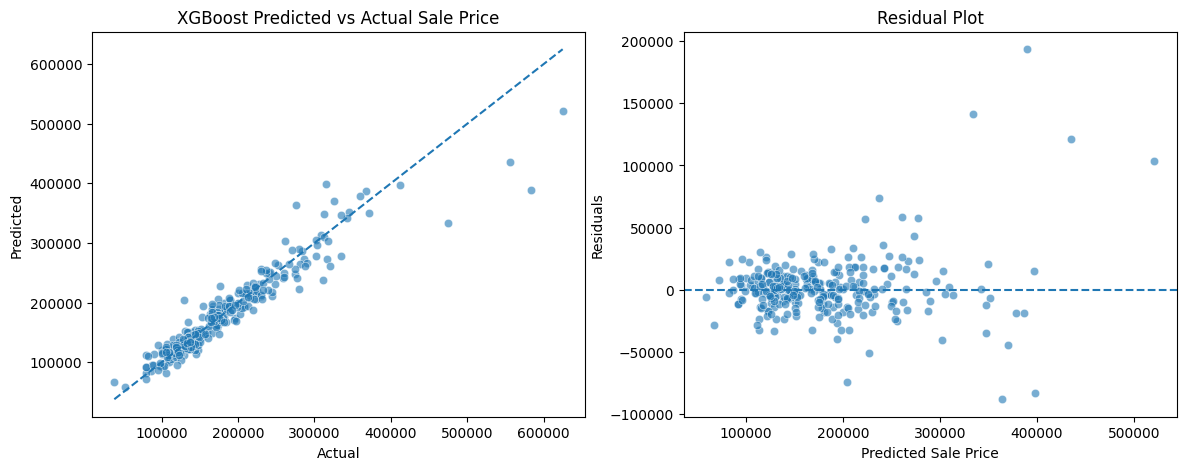

In [24]:
# Predicted vs Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x=y_test_dollar, y=pred_dollar_xgb, alpha=0.6, ax=axes[0])
axes[0].plot([y_test_dollar.min(), y_test_dollar.max()],
         [y_test_dollar.min(), y_test_dollar.max()],
         linestyle="--")

axes[0].set_title("XGBoost Predicted vs Actual Sale Price")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Residual Plot
residuals = (y_test_dollar - pred_dollar_xgb)
sns.scatterplot(x=pred_dollar_xgb, y=residuals, alpha=0.6, ax=axes[1])

axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Sale Price")
axes[1].set_ylabel("Residuals")

plt.show()

To further evaluate the final XGBoost model, predicted sale prices were compared with the actual values in the test set. The predicted-versus-actual plot shows that most observations fall close to the 45-degree reference line, indicating that the model generally produced accurate predictions across much of the price range.

The model performed particularly well for properties in the lower and middle price ranges, where the predictions were tightly concentrated around the reference line. However, several of the highest-priced homes were predicted below their actual values, suggesting that the model tended to underestimate some expensive properties.

The residual plot provides a closer view of the prediction errors. Most residuals were centered around zero, which indicates that the model did not show a strong overall tendency to consistently overpredict or underpredict sale prices. However, the spread of the residuals increased for higher predicted prices, and several large positive residuals were present. This suggests that prediction errors were greater among more expensive properties and that some high-value homes were substantially underpredicted.

Overall, the diagnostic plots support the model's strong test performance while also showing that predictions were less precise at the upper end of the housing market.

## 8. Feature Influence Under XGBoost



In [25]:
# Extract fitted preprocessor and XGBoost model

xgb_preprocessor = best_xgb_model.named_steps["preprocessor"]
xgb_model = best_xgb_model.named_steps["model"]

# Get transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Remove tranformer prefixes
feature_names = [
    name.replace("num_zero__", "")
        .replace("num_median__", "")
        .replace("cat_mode__", "")
        .replace("cat_none__", "")
    for name in feature_names
]

# Create feature importance DataFrame
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance.sort_values("Importance", ascending=False).head(10).
    reset_index(drop=True)
)

xgb_importance

,Feature,Importance
0,OverallQual,0.143847
1,ExterQual_TA,0.119169
2,Age,0.060578
3,GarageCars,0.048710
4,MSZoning_RM,0.045915
5,GrLivArea,0.041972
6,Fireplaces,0.039448
7,CentralAir_N,0.034893
8,BsmtQual_Ex,0.029153
9,TotalBsmtSF,0.020685


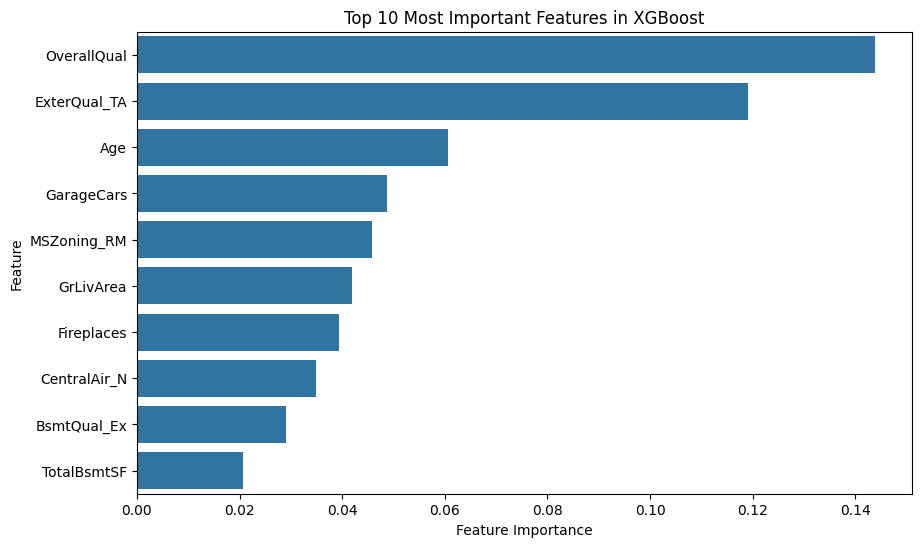

In [26]:
# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features in XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

Feature importance was examined to better understand which predictors were most useful to the final XGBoost model. Overall quality was the most important feature, followed by exterior quality and property age. Garage capacity, living area, basement quality, and total basement area also contributed to the model's predictions.

Several categorical levels, such as MSZoning_RM and CentralAir_N, appeared among the top features after one-hot encoding. These represent specific categories within their original variables rather than the overall importance of the entire categorical feature.

These importance values describe how useful each transformed feature was to the fitted XGBoost model. They should not be interpreted as causal effects or as the dollar amount by which changing a feature would affect a home's sale price.

Overall, the results suggest that the model relied primarily on measures of property quality, age, size, and key structural characteristics when generating its predictions.

## 9. Conclusion

Among the models evaluated, XGBoost achieved the strongest validation performance and was selected as the final model. On the held-out test set, the model achieved a log RMSE of 0.1110, a mean absolute error of approximately $14,775, and a mean absolute percentage error of 8.11%.

The final model produced accurate predictions across much of the observed price range, particularly for homes in the lower and middle price ranges. Prediction errors increased for some higher-priced properties, indicating that the model was less precise at the upper end of the housing market.

Feature importance results showed that overall quality, exterior quality, property age, garage capacity, and above-ground living area were among the most influential predictors used by XGBoost. These findings were generally consistent with patterns identified during exploratory data analysis.

Overall, the results suggest that tree-based ensemble methods were well suited to capturing the nonlinear relationships and interactions present in the housing data. Future improvements could include more extensive hyperparameter tuning, additional feature engineering, and further investigation of high-value properties to improve prediction accuracy in the upper price range.

**Future Improvements**

A few improvements could be explored in future versions of this project. First, additional feature engineering could be performed by creating variables such as total square footage, total number of bathrooms, remodeling age, and interactions between property quality and size. These features may help the models capture relationships that are not fully represented by the original variables.

The hyperparameter search could also be expanded, particularly for XGBoost, Random Forest, and the neural network. A wider randomized or Bayesian search could identify stronger model configurations while remaining more computationally efficient than an grid search. The deep learning model could also be improved by testing different architectures, learning rates, regularization methods, and batch sizes.

Finally, future work could examine how well the modeling approach generalizes beyond the Ames housing market. Because the model was trained using data from Ames, Iowa, its predictions may not transfer well to locations with different prices, neighborhood structures, housing styles, and market conditions. This could be investigated by evaluating the model on external data and, if necessary, retraining it using data from multiple locations or more recent time periods. Doing so would help determine whether the approach can be adapted to broader housing markets.